# Research Notebook: Vicious Circle Analysis

## About
Notebook for clustering and correlation analysis on socio-economic vulnerability and disability dataset.

---

## Notebook Structure

### Setup (run first!)
| Cell | Description |
|------|-------------|
| Imports | Load libraries |
| Environment | Mount Drive (Colab) or set local path |
| Functions | Data loading & processing functions |
| Load Data | Load and merge all datasets |
| Rates & Indices | Calculate rates, build health indices by age group |
| Data Prep | Create working dataset |

### Cluster Analysis (K-Means)
Discover natural groupings using Elbow Method + K-Means.

### Correlation Visualizations
Explore relationships between social vulnerability and health outcomes.

---

## Key Variables
- `social_index` — composite vulnerability (higher = worse)
- `working_age_health_index` — disability burden ages 18-64 (higher = worse)
- `elderly_health_index` — long-term care burden ages 65+ (higher = worse)
- `child_health_index` — disabled children rate ages 0-17 (higher = worse)
- `total_population` — settlement size

In [30]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style - красивая тема
sns.set_theme(style="whitegrid", palette="Set1", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [31]:
# === ENVIRONMENT SETUP ===
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_PATH = "/content/drive/MyDrive/datas_for_research_vicious_circle_project (1)"
else:
    # Local path - adjust if needed
    BASE_PATH = r"C:\Users\kiril\OneDrive\Desktop\My_projects\TovTechOrg\bituah_da\datas_for_research_vicious_circle_project"

os.chdir(BASE_PATH)
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\kiril\OneDrive\Desktop\My_projects\TovTechOrg\bituah_da\datas_for_research_vicious_circle_project


In [32]:
# === DATA LOADING FUNCTIONS ===

def load_data(paths):
    return {
        "benefits": pd.read_excel(paths["benefits"], header=None),
        "lamas": pd.read_excel(paths["lamas"], sheet_name="נתונים פיזיים ונתוני אוכלוסייה ", header=None),
        "socio_regional": pd.read_excel(paths["socio_regional"], header=None),
        "periph_regional": pd.read_excel(paths["periph_regional"], header=None),
        "coordinates": pd.read_csv(paths["coordinates"])
    }

def merge_lamas(df_benefits, df_lamas):
    before = len(df_benefits)
    df = df_benefits.merge(
        df_lamas[["settlement_symbol", "socio_economic_index_cluster",
                  "socio_economic_index_score", "peripherality_index_cluster",
                  "peripherality_index_score"]],
        on="settlement_symbol", how="left"
    )
    assert len(df) == before, f"Lost rows in LAMAS merge: {before} -> {len(df)}"
    return df

def merge_index_from_regional(df_main, df_regional, index_cols, key="settlement_symbol"):
    before = len(df_main)
    df = df_main.merge(df_regional[[key] + index_cols], on=key, how="left", suffixes=("", "_reg"))
    assert len(df) == before, f"Row count mismatch: {before} -> {len(df)}"
    for col in index_cols:
        df[col] = df[col].combine_first(df[f"{col}_reg"])
    df = df.drop(columns=[f"{col}_reg" for col in index_cols])
    return df

def merge_coordinates(df_main, df_coordinates):
    before = len(df_main)
    df = df_main.merge(
        df_coordinates[["settlement_code", "lat", "lon"]],
        left_on="settlement_symbol", right_on="settlement_code", how="left"
    )
    df = df.drop(columns=["settlement_code"])
    assert len(df) == before, f"Lost rows in COORDINATES merge: {before} -> {len(df)}"
    return df

def clean_values(df):
    df = df.replace("***", np.nan)
    last_4_cols = df.columns[-4:]
    df = df.dropna(subset=last_4_cols, how="all")

    cols_to_drop = ["settlement_type", "injury_allowance", "recipients_of_the_senior_citizen_pension_only",
                    "recipients_of_the_pension_with_income_supplementation",
                    "total_recipients_of_old_age_and/or_survivors'_benefits",
                    "num_families_receiving_child_benefit", "num_children_receiving_child_benefit",
                    "families_with_4+_children_receiving_child_benefit", "maternity_benefits", "alimony"]
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

    categorial_cols = ["socio_economic_index_cluster", "peripherality_index_cluster"]
    numeric_cols = df.loc[:, "total_population":"unemployment_benefit"].columns
    float_cols = ["socio_economic_index_score", "peripherality_index_score", "lon", "lat"]

    for col in df.columns:
        if col in categorial_cols:
            df[col] = df[col].astype("category")
        elif col in numeric_cols:
            df[col] = df[col].astype(str).str.replace(",", "", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)
        elif col in float_cols:
            df[col] = df[col].astype(float)
        else:
            df[col] = df[col].astype("object")
    return df

print("Functions loaded!")

Functions loaded!


In [33]:
# === LOAD AND PROCESS DATA ===

paths = {
    "benefits": "benefits_2024_12.xlsx",
    "lamas": "p_libud_23.xlsx",
    "socio_regional": "24_24_230t3.xlsx",
    "periph_regional": "24_22_420t3.xlsx",
    "coordinates": "israel_settlements_all_with_coords.csv"
}

dfs = load_data(paths)

# Process benefits
df_benefits = dfs["benefits"].iloc[5:].copy().reset_index(drop=True)
df_benefits.columns = [
    "settlement_name", "settlement_symbol", "settlement_type",
    "total_population", "population_0_17", "population_18_64", "population_65_plus",
    "total_recipients_of_old_age_and/or_survivors'_benefits",
    "recipients_of_the_pension_with_income_supplementation",
    "recipients_of_the_senior_citizen_pension_only",
    "long_term_care_benefit", "general_disability_benefit",
    "special_services_for_persons_with_disabilities", "disabled_child_benefit",
    "mobility_benefit", "work_injury_victims_receiving_disability_and_dependents'_benefits",
    "injury_allowance", "num_families_receiving_child_benefit",
    "num_children_receiving_child_benefit", "families_with_4+_children_receiving_child_benefit",
    "maternity_benefits", "alimony", "income_support_benefit", "unemployment_benefit"
]

# Process LAMAS
df_lamas = dfs["lamas"].iloc[9:].copy().reset_index(drop=True)
df_lamas = df_lamas[df_lamas[3] != 'מועצה אזורית']
df_lamas.rename(columns={1: "settlement_symbol", 250: "socio_economic_index_cluster",
                         251: "socio_economic_index_score", 256: "peripherality_index_cluster",
                         257: "peripherality_index_score"}, inplace=True)

# Process regional data
df_socio = dfs["socio_regional"].iloc[10:].copy().reset_index(drop=True).iloc[:-8]
df_socio.rename(columns={5: "settlement_symbol", 12: "socio_economic_index_cluster",
                         10: "socio_economic_index_score"}, inplace=True)

df_periph = dfs["periph_regional"].iloc[9:].copy().reset_index(drop=True).iloc[:-4]
df_periph.rename(columns={4: "settlement_symbol", 12: "peripherality_index_cluster",
                          10: "peripherality_index_score"}, inplace=True)

# Merge all
data_master = merge_lamas(df_benefits, df_lamas)
data_master = merge_index_from_regional(data_master, df_socio,
    index_cols=["socio_economic_index_cluster", "socio_economic_index_score"])
data_master = merge_index_from_regional(data_master, df_periph,
    index_cols=["peripherality_index_cluster", "peripherality_index_score"])
data_master = merge_coordinates(data_master, dfs["coordinates"])
data_master = clean_values(data_master)

print(f"Loaded {len(data_master)} settlements")

Loaded 278 settlements


In [34]:
# === CALCULATE RATES AND INDICES (IMPROVED) ===

# 1. Calculate rates
data_master['general_disability_rate'] = (data_master['general_disability_benefit'] / data_master['population_18_64'] * 100).round(2)
data_master['special_services_disability_rate'] = (data_master['special_services_for_persons_with_disabilities'] / data_master['population_18_64'] * 100).round(2)
data_master['mobility_disability_rate'] = (data_master['mobility_benefit'] / data_master['population_18_64'] * 100).round(2)
data_master['long_term_care_rate'] = (data_master['long_term_care_benefit'] / data_master['population_65_plus'] * 100).round(2)
data_master['disabled_child_rate'] = (data_master['disabled_child_benefit'] / data_master['population_0_17'] * 100).round(2)

# 2. Social Index (clean - only exogenous factors)
social_cols = ['socio_economic_index_score', 'peripherality_index_score']
df_social = data_master[social_cols].copy()
df_social['socio_economic_index_score'] *= -1
df_social['peripherality_index_score'] *= -1
data_master['social_index'] = StandardScaler().fit_transform(df_social).mean(axis=1)

# 3. Health Indices (split by age group)
working_age_cols = ['general_disability_rate', 'special_services_disability_rate', 'mobility_disability_rate']
data_master['working_age_health_index'] = StandardScaler().fit_transform(data_master[working_age_cols]).mean(axis=1)

elderly_cols = ['long_term_care_rate']
data_master['elderly_health_index'] = StandardScaler().fit_transform(data_master[elderly_cols]).mean(axis=1)

child_cols = ['disabled_child_rate']
data_master['child_health_index'] = StandardScaler().fit_transform(data_master[child_cols]).mean(axis=1)

print("Indices calculated!")

Indices calculated!


## Data Preparation for Analysis

Create working dataset with key variables for clustering and correlation analysis.

In [35]:
df_work = data_master[[
    "settlement_name",
    "social_index",
    "working_age_health_index",
    "elderly_health_index",
    "child_health_index",
    "total_population"
]].copy()

df_work = df_work.dropna()
df_work["log_population"] = np.log1p(df_work["total_population"])
df_work["pct_elderly"] = data_master.loc[df_work.index, "population_65_plus"] / data_master.loc[df_work.index, "total_population"]
df_work["pct_children"] = data_master.loc[df_work.index, "population_0_17"] / data_master.loc[df_work.index, "total_population"]

print(f"Total settlements: {len(df_work)}")


Total settlements: 232


## Cluster Analysis (K-Means)

### The Elbow Method
To find the optimal number of clusters (K):
1. Run K-Means for K = 1, 2, 3, ... 10
2. Calculate **inertia** (within-cluster sum of squares)
3. Plot inertia vs K — look for the "elbow" where adding more clusters stops helping much

### Features for Clustering
- `social_index` — socio-economic vulnerability
- `working_age_health_index` — disability/health burden (ages 18-64)
- `child_health_index` — disabled children rate (ages 0-17)
- `pct_elderly` — share of population 65+
- `log_population` — settlement size

c:\Users\kiril\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kiril\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kiril\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kiril\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

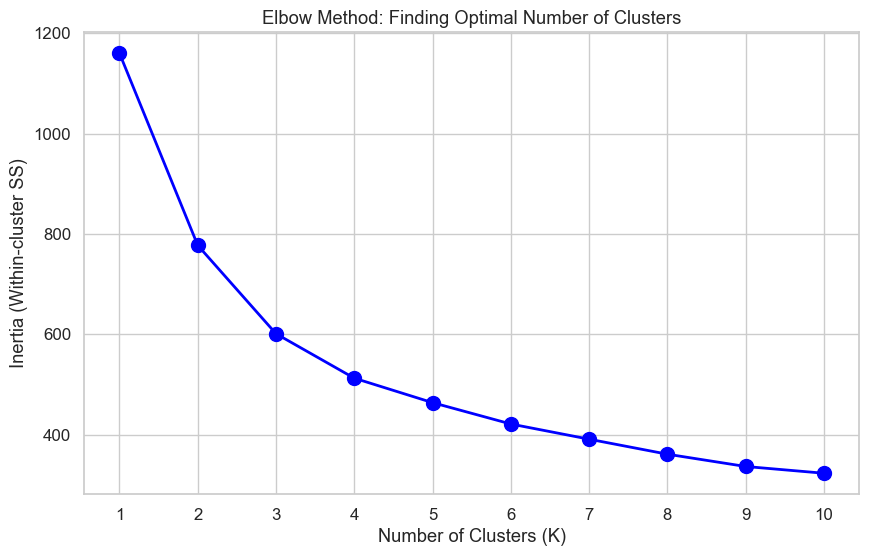

c:\Users\kiril\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Applied K-Means with K=3
Cluster distribution:
cluster
0     61
1    108
2     63
Name: count, dtype: int64


In [36]:
# === CLUSTERING: ELBOW METHOD + K-MEANS ===

# Features for clustering
cluster_features = [
    "social_index",
    "working_age_health_index",
    "child_health_index",
    "pct_elderly",
    "log_population"
]
X_cluster = df_work[cluster_features].dropna().to_numpy()

# Standardize
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# === ELBOW METHOD ===
k_range = range(1, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster SS)')
plt.title('Elbow Method: Finding Optimal Number of Clusters')
plt.xticks(k_range)
plt.show()

# === APPLY CLUSTERING WITH OPTIMAL K ===
OPTIMAL_K = 3  # Based on elbow

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_work["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

print(f"\nApplied K-Means with K={OPTIMAL_K}")
print(f"Cluster distribution:\n{df_work['cluster'].value_counts().sort_index()}")

## Key Research Findings

### How We Calculate the Indices

**Social Index** (higher = more vulnerable):
- Combines: `socio_economic_index_score` (inverted) + `peripherality_index_score` (inverted)
- Normalized using StandardScaler
- Poor peripheral towns → high positive values; Rich central towns → negative values

**Health Indices** (higher = worse health outcomes):
- `working_age_health_index` = general_disability_rate + special_services_rate + mobility_rate (ages 18-64)
- `child_health_index` = disabled_child_rate (ages 0-17)
- `elderly_health_index` = long_term_care_rate (ages 65+)

All rates are calculated as: `(benefit_recipients / age_group_population) × 100`

---

### What the Clusters Reveal

| Cluster | Social Index | Adult Health | Child Health | Profile |
|---------|-------------|--------------|--------------|---------|
| **0** | -0.72 (affluent) | -0.87 (healthy) | -0.17 | Wealthy suburbs |
| **1** | +0.62 (poor) | +0.48 (sick) | **-0.34** (healthy?!) | Arab + Haredi towns |
| **2** | -0.31 (medium) | +0.37 (medium) | **+1.35** (crisis!) | Large cities |

---

### 3 Key Insights

#### 1. Vicious Circle Confirmed (Cluster 1)
- **Finding:** Poor towns have high adult disability rates
- **Correlation:** r = +0.45 (strong positive relationship)
- **Meaning:** Poverty → Disability → More Poverty (cycle)

#### 2. The Child Paradox (Cluster 1)
- **Finding:** Despite high adult disability, child disability is LOW in poor towns
- **Why strange:** If adults are sick, why are children "healthy"?
- **Hypothesis:** **Underdiagnosis** — poor families don't access healthcare, children don't get diagnosed
- **Implication:** Hidden crisis — children not receiving needed services

#### 3. Urban Child Crisis (Cluster 2)
- **Finding:** Large cities (Jerusalem, Tel Aviv) have EXTREMELY high child disability (+1.35)
- **Possible explanations:**
  - Better access to diagnosis in cities? (detection bias)
  - Real environmental/social factors in urban areas?
- **Research question:** Is this a real crisis or better detection?

---

### Policy Implications

> "One size does NOT fit all" — Different clusters require different interventions:
> - Cluster 1: Focus on **early diagnosis** and **healthcare access** for children
> - Cluster 2: Investigate **causes** of high child disability in cities
> - Cluster 0: Use as **benchmark** for healthy outcomes

In [37]:
# === CLUSTER SUMMARY ===

cluster_summary = df_work.groupby("cluster").agg({
    "social_index": "mean",
    "working_age_health_index": "mean",
    "child_health_index": "mean",
    "elderly_health_index": "mean",
    "pct_elderly": "mean",
    "pct_children": "mean",
    "total_population": ["mean", "count"]
}).round(3)

print(f"=== Cluster Summary (K={OPTIMAL_K}) ===\n")
print(cluster_summary)

# === ПОСМОТРИМ КАКИЕ ГОРОДА В КАЖДОМ КЛАСТЕРЕ ===
print("\n" + "="*60)
print("SETTLEMENTS IN EACH CLUSTER (sorted by population)")
print("="*60)

for cluster in sorted(df_work["cluster"].unique()):
    subset = df_work[df_work["cluster"] == cluster].sort_values("total_population", ascending=False)
    print(f"\n--- CLUSTER {cluster} ({len(subset)} settlements) ---")
    print("Top 15 by population:")
    for i, (_, row) in enumerate(subset.head(15).iterrows()):
        print(f"  {i+1}. {row['settlement_name']} (pop: {int(row['total_population']):,})")

=== Cluster Summary (K=3) ===

        social_index working_age_health_index child_health_index  \
                mean                     mean               mean   
cluster                                                            
0             -0.717                   -0.869             -0.166   
1              0.618                    0.479             -0.344   
2             -0.306                    0.366              1.354   

        elderly_health_index pct_elderly pct_children total_population        
                        mean        mean         mean             mean count  
cluster                                                                       
0                     -0.915       0.119        0.324        15416.295    61  
1                      0.894       0.064        0.353        15355.250   108  
2                     -0.215       0.158        0.292        98823.937    63  

SETTLEMENTS IN EACH CLUSTER (sorted by population)

--- CLUSTER 0 (61 settlements) --

## Research Findings: Vicious Circle Analysis

### Cluster Interpretation

After running the notebook, look at:
1. **Cluster Summary** — which cluster has high/low social_index and health_index?
2. **Settlements per cluster** — what type of cities are in each cluster?

### Key Questions to Answer:

- Which cluster shows the **"vicious circle"** (high social vulnerability + high disability)?
- Which cluster has **healthy outcomes** despite social factors?
- Which cluster shows **high child disability** (future risk)?

### Correlation Analysis

Look at the correlation by cluster:
- **Positive correlation (r > 0.3)** = vicious circle confirmed
- **Near zero correlation (r ≈ 0)** = no relationship
- **Negative correlation (r < -0.3)** = unexpected pattern

### Notes

- Cluster numbers (0, 1, 2) are arbitrary — focus on the characteristics
- Name clusters based on the actual settlements you see in each group

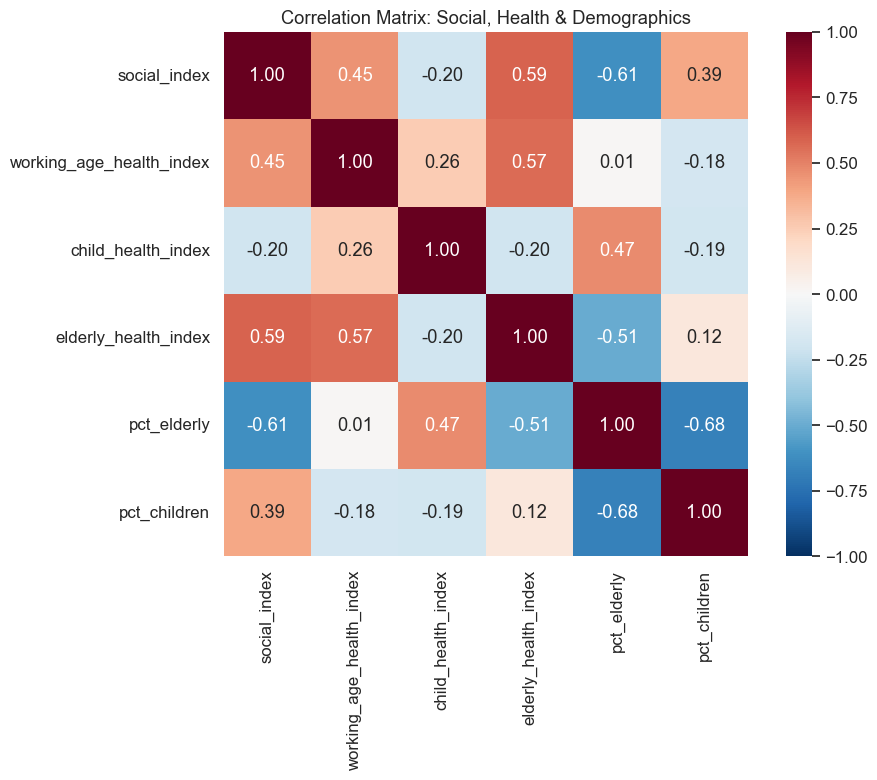

In [38]:
# === CORRELATION HEATMAP ===

corr_cols = ["social_index", "working_age_health_index", "child_health_index",
             "elderly_health_index", "pct_elderly", "pct_children"]

corr_matrix = df_work[corr_cols].corr().round(3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    fmt=".2f"
)
plt.title("Correlation Matrix: Social, Health & Demographics")
plt.tight_layout()
plt.show()

c:\Users\kiril\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kiril\AppData\Local\Temp\ipykernel_26468\3022638079.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


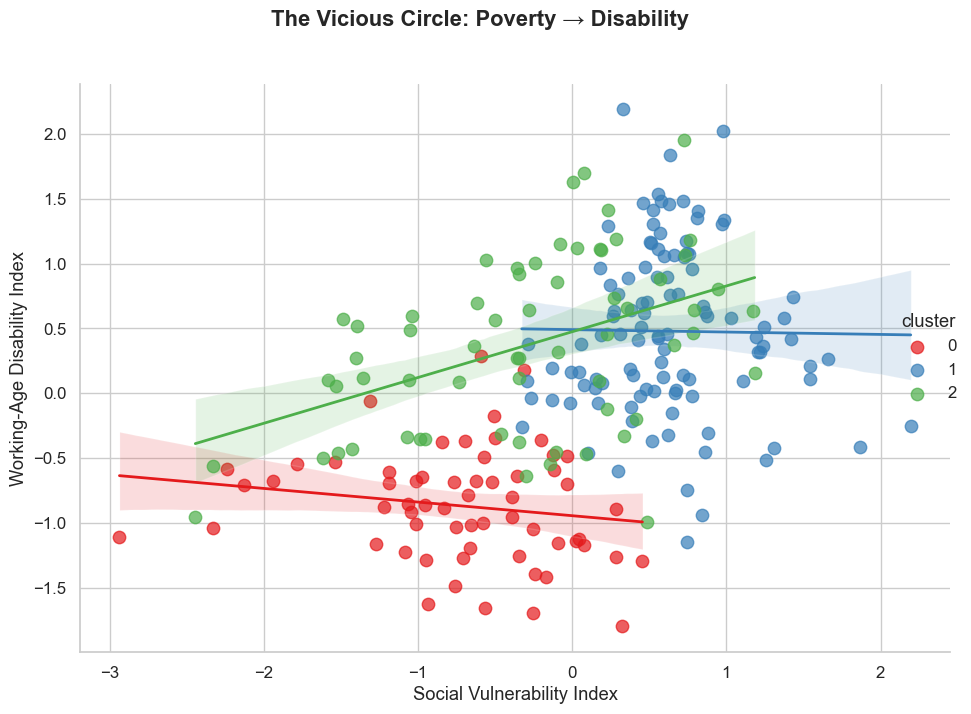

In [39]:
# === MAIN RELATIONSHIP: Social vs Working-Age Health ===

g = sns.lmplot(
    data=df_work,
    x="social_index",
    y="working_age_health_index",
    hue="cluster",
    palette="Set1",
    height=7,
    aspect=1.3,
    scatter_kws={"s": 80, "alpha": 0.7},
    line_kws={"linewidth": 2}
)
g.set_axis_labels("Social Vulnerability Index", "Working-Age Disability Index")
g.figure.suptitle("The Vicious Circle: Poverty → Disability", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

c:\Users\kiril\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kiril\AppData\Local\Temp\ipykernel_26468\3324946269.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


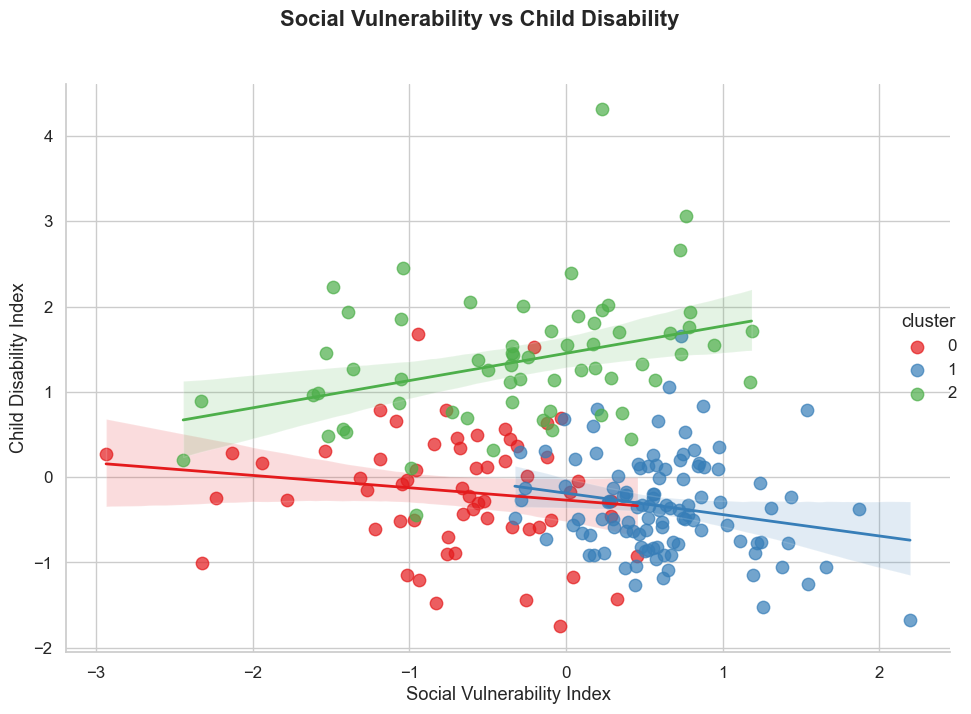

In [40]:
# === SURPRISING FINDING: Social vs Child Health ===

g = sns.lmplot(
    data=df_work,
    x="social_index",
    y="child_health_index",
    hue="cluster",
    palette="Set1",
    height=7,
    aspect=1.3,
    scatter_kws={"s": 80, "alpha": 0.7},
    line_kws={"linewidth": 2}
)
g.set_axis_labels("Social Vulnerability Index", "Child Disability Index")
g.figure.suptitle("Social Vulnerability vs Child Disability", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

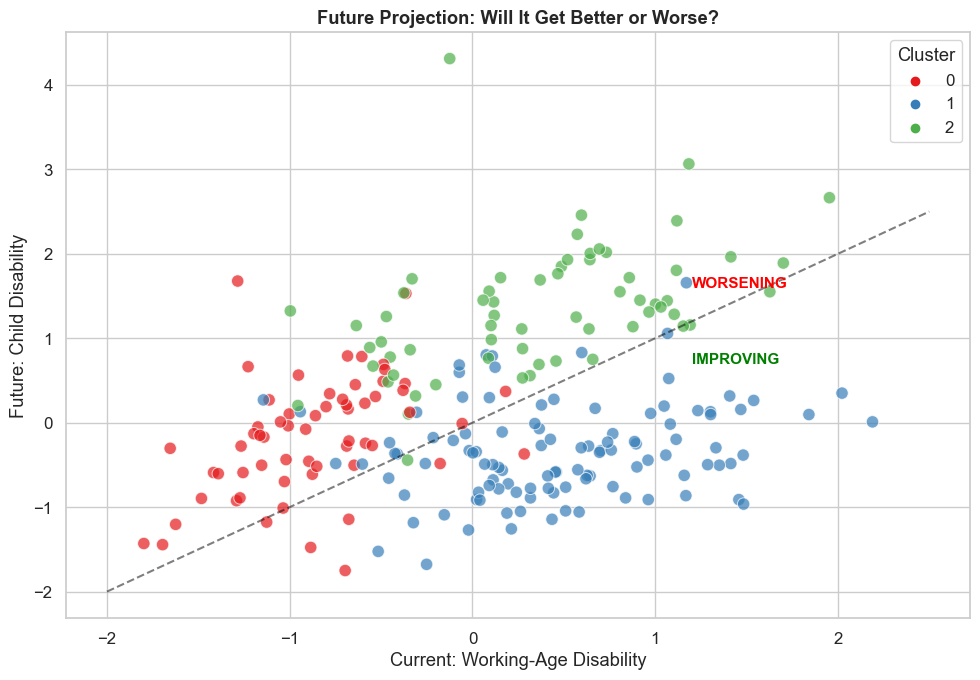

In [41]:
# === FUTURE PROJECTION: Working-Age vs Child Health ===

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_work,
    x="working_age_health_index",
    y="child_health_index",
    hue="cluster",
    s=80,
    alpha=0.7,
    palette="Set1"
)

# Diagonal line
plt.plot([-2, 2.5], [-2, 2.5], 'k--', alpha=0.5, linewidth=1.5)
plt.text(1.2, 1.6, "WORSENING", color="red", fontsize=11, fontweight='bold')
plt.text(1.2, 0.7, "IMPROVING", color="green", fontsize=11, fontweight='bold')

plt.xlabel("Current: Working-Age Disability")
plt.ylabel("Future: Child Disability")
plt.title("Future Projection: Will It Get Better or Worse?", fontweight='bold')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

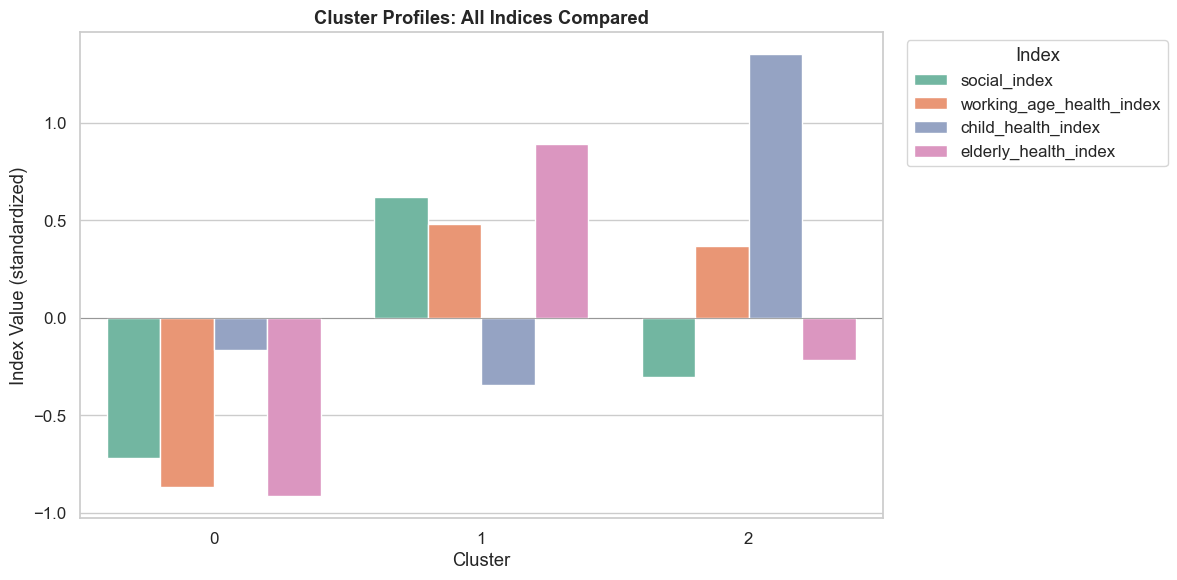

In [42]:
# === CLUSTER COMPARISON BAR CHART ===

cluster_stats = df_work.groupby("cluster")[
    ["social_index", "working_age_health_index", "child_health_index", "elderly_health_index"]
].mean().reset_index()

cluster_stats_melted = cluster_stats.melt(
    id_vars="cluster",
    var_name="Index",
    value_name="Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=cluster_stats_melted,
    x="cluster",
    y="Value",
    hue="Index",
    palette="Set2"
)
plt.xlabel("Cluster")
plt.ylabel("Index Value (standardized)")
plt.title("Cluster Profiles: All Indices Compared", fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.legend(title="Index", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

CORRELATION: Social → Working-Age Health BY CLUSTER
Cluster 0: r = -0.165 (n=61)
Cluster 1: r = -0.013 (n=108)
Cluster 2: r = 0.438 (n=63)


c:\Users\kiril\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kiril\AppData\Local\Temp\ipykernel_26468\3757917919.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


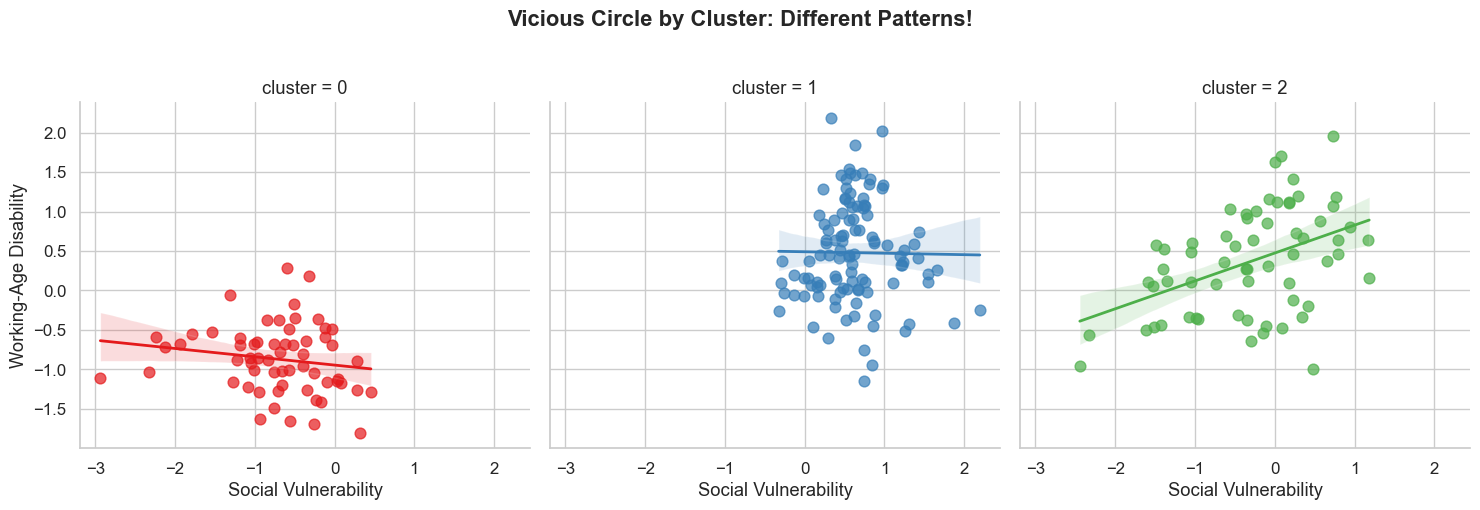

In [43]:
# === CORRELATION BY CLUSTER ===

print("=" * 60)
print("CORRELATION: Social → Working-Age Health BY CLUSTER")
print("=" * 60)

for cluster in sorted(df_work["cluster"].unique()):
    subset = df_work[df_work["cluster"] == cluster]
    corr = subset["social_index"].corr(subset["working_age_health_index"])
    n = len(subset)
    print(f"Cluster {cluster}: r = {corr:.3f} (n={n})")

# === FACETED PLOT BY CLUSTER ===

g = sns.lmplot(
    data=df_work,
    x="social_index",
    y="working_age_health_index",
    col="cluster",
    hue="cluster",
    palette="Set1",
    height=5,
    aspect=1,
    scatter_kws={"s": 60, "alpha": 0.7},
    line_kws={"linewidth": 2},
    legend=False
)

g.set_axis_labels("Social Vulnerability", "Working-Age Disability")
g.figure.suptitle("Vicious Circle by Cluster: Different Patterns!", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()